# Changing the resolution of a return period map

In this notebook we demonstrate how one can use the sampling methods to combine different exceedance curves to change the resultion of a return period map. 

The idea of a return period map show, for each pixel of a map, the exceedance values for a given return period. An example would be a floop map corresponding to a 100 year return period. THis maps does NOT show a 100 year flood but, at each pixel, the 100 year flood height at this specific locaiton. One of the complication of these maps is that they are inherently resolution-dependent. Here we show how we can coarsen the resolution of a return period map.

The central object here are instances of the class `ReturnPeriodMap` that are essentially just lists of `ExceedanceCurve` objects, and a geometry attribute indicating the coordinate of each exceedance curve. `ReturnPeriodMap` objects have the method `coarsen` that return a new object of the class with a coarsened resolution.

## Define a return period map from CLIMADA data and functionality

We now first define an exemplary imapct return period map, using impacts computed from the CLIMADA data API (historical TCs in haiti with some resampling, with some expoure and vulnerability information).

In [53]:
# import warnings

# warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from climada.entity import ImpactFuncSet, ImpfTropCyclone
from climada.engine import ImpactCalc
from climada.util.api_client import Client
from climada.util.plot import plot_from_gdf
from climada.util.constants import CMAP_IMPACT

from exceedance_curve_tools.return_period_maps import ReturnPeriodMap

client = Client()
# hazard data
haz_tc_haiti = client.get_hazard(
    "tropical_cyclone",
    properties={
        "country_name": "Haiti",
        "climate_scenario": "historical",
        "nb_synth_tracks": "10",
    },
)

# exposure data
exposure = client.get_litpop(country="Haiti")
exposure.data["value"] /= 1_000_000
exposure.value_unit = "USD million"

# impact function
impf_tc = ImpfTropCyclone.from_emanuel_usa()
impf_set = ImpactFuncSet([impf_tc])

impact = ImpactCalc(exposure, impf_set, haz_tc_haiti).impact()

We now use CLIMADA functionality to obtain local impact exceedance curves for a number of user-specified return periods. As discussed in this notebook about estimating AAI from exceedance curves, we use a high resolution of return periods to later avoid numerical errors. We use the resolution geodataframe to intanciate a `ReturnPeriodMap` object.

In [ ]:
rps = np.geomspace(1, 450, 300)
local_exceedance_impact, _, _ = impact.local_exceedance_impact(return_periods=rps, method="extrapolate_constant")
rp_map = ReturnPeriodMap.from_climada_local_exceedance_impact(local_exceedance_impact)

To visualize, we plot a few return period maps for some common return period values.

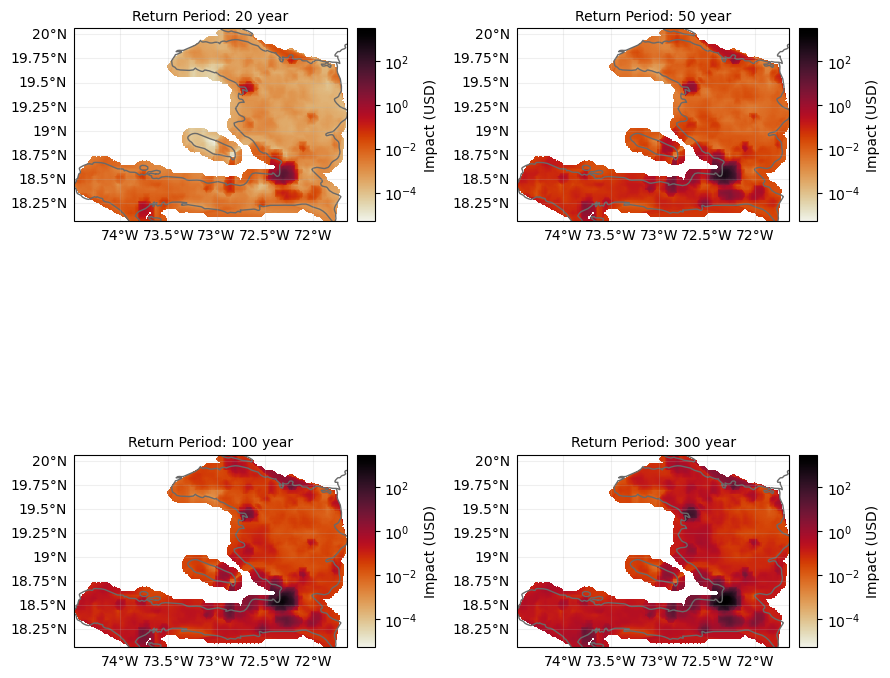

In [80]:
plot_rps = [20, 50, 100, 300]
vmin, vmax = 1e-4, 1e4
gdf, title, label = rp_map.get_local_exceedance_values(plot_rps, method="extrapolate_constant")
plot_from_gdf( gdf, title, label, cmap=CMAP_IMPACT);

## Coarsening the resolution of the return period maps

Now, we want to coarsen the resolution of the return period maps. Here we coarsen by a factor of 2 which means that we have to combine up to four exceedance curves into one. The method `coarsen` does this using the sampling functionality described in this [notebook](combine_two_exceedance_curves.ipynb).

As combination parameters, we use a `correlation_factor = 0.9` to model for correlations between the occurence of impacts between neighboring pixels. Also, we choose `coincidence_fraction = 0.5` meaning that we consider two events happening coincidentally if they occur during the same 6 months.

To compare, we also coarsen the map using the same parameters but a `coincidence_fraction = 1/52`, meaning that we consider two events happening coincidentally if they occur in the same week. This results in a sampling with much less compound impacts.

In [144]:
correlation_factor = .9
n_samples = 20000
coincidence_fraction = 0.5
coicidence_fraction_short = 1/52
aggregation_method=sum

rp_map_half =  rp_map.coarsen(scale_factor=2, aggregation_method=aggregation_method, coincidence_fraction=coincidence_fraction, n_samples=n_samples, correlation_factor=correlation_factor,)

rp_map_half_short =  rp_map.coarsen(scale_factor=2, coincidence_fraction=coicidence_fraction_short, n_samples=n_samples,correlation_factor=correlation_factor,)


First, we briefly check that coarsening transforms the old geometry to the new one in the way we wanted.

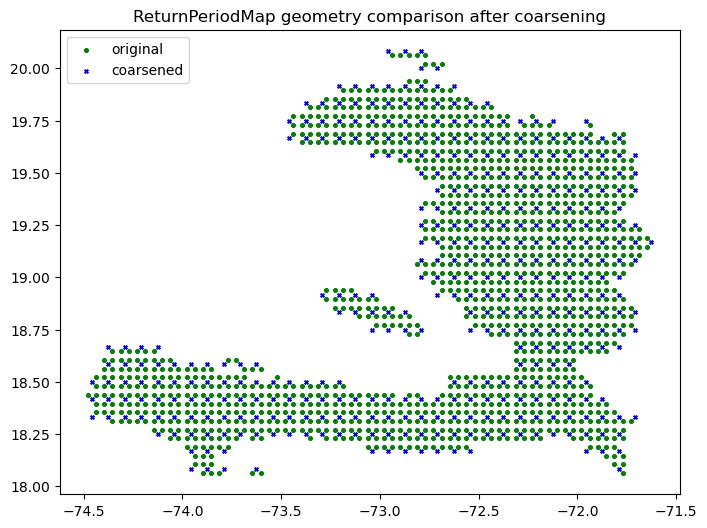

In [137]:
fig, ax  = plt.subplots(1, 1, figsize=(8, 8))
rp_map.geometry.plot(ax=ax, color="green", markersize=7, label="original")
rp_map_half.geometry.plot(ax=ax, color="blue", markersize=7, label="coarsened", marker="x");
ax.set_title("ReturnPeriodMap geometry comparison after coarsening")
ax.legend(loc="upper left");

Now, we can analyse how the return period maps changed after chaning the resolution, for two exemplary return periods.

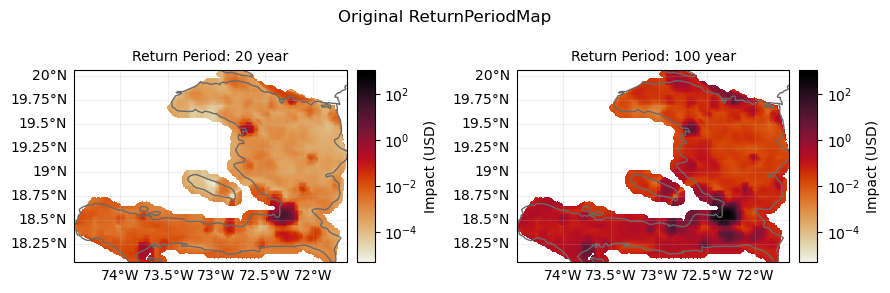

In [146]:
plot_rps = [20, 100]
vmin, vmax = 1e-4, 1e4
gdf, title, label = rp_map.get_local_exceedance_values(plot_rps, method="extrapolate_constant")
ax = plot_from_gdf(gdf, title, label, cmap=CMAP_IMPACT);
ax[0].get_figure().suptitle("Original ReturnPeriodMap", fontsize=12, y=.62);

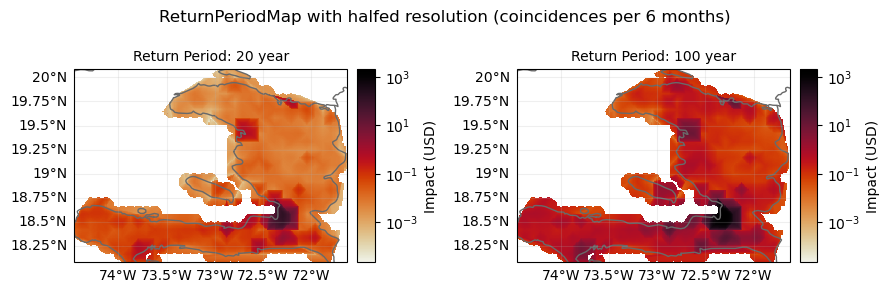

In [147]:
plot_rps = [20, 100]
vmin, vmax = 1e-4, 1e4
gdf, title, label = rp_map_half.get_local_exceedance_values(plot_rps, method="extrapolate_constant")
ax = plot_from_gdf(gdf, title, label, cmap=CMAP_IMPACT);
ax[0].get_figure().suptitle("ReturnPeriodMap with halfed resolution (coincidences per 6 months)", fontsize=12, y=.62);

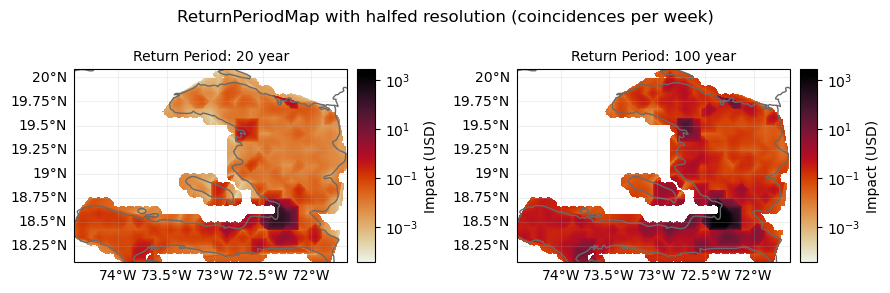

In [148]:
plot_rps = [20, 100]
vmin, vmax = 1e-4, 1e4
gdf, title, label = rp_map_half_short.get_local_exceedance_values(plot_rps, method="extrapolate_constant")
ax = plot_from_gdf(gdf, title, label, cmap=CMAP_IMPACT);
ax[0].get_figure().suptitle("ReturnPeriodMap with halfed resolution (coincidences per week)", fontsize=12, y=.62);

## Computing average annual impacts

As discussed in the [notebook about computing the AAI from exceedance curves](estimate_AAI.ipynb), the average annual impact (AAI) can be computed from the return period map. Here, we compute the AAI before and after coarsening the resolution of the return period map. As discussed in and the [notebook about computing the AAI from exceedance curves](estimate_AAI.ipynb), as we combine exceedance curves using the probability in a given time window (and not the frequency), combining them can alter the AAI. Of course, sampling also adds to discprecancies between AAIs.

## RP map plots before and after changing resolution

In [ ]:
print(f"{rp_map.compute_aai_aggregated()} (AAI computed from the original return period map)")
print(f"{rp_map_half.compute_aai_aggregated()} (AAI computed from the original return period map)")
print(f"{rp_map_half_short.compute_aai_aggregated()} (AAI computed from the original return period map)")


201.34732252262884 (AAI computed from the original return period map)
190.23013103339582 (AAI computed from the original return period map)
215.42107809018526 (AAI computed from the original return period map)
